## Setup

In [2]:
# Core libraries
from openai import OpenAI
from tqdm import trange
import pandas as pd
import time
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Connect to the provider
client = OpenAI(
    base_url="https://api.deepinfra.com/v1/openai",
    api_key="tQ9NcgoVBuIQYplJ1yyMtaTMAUTFqQ0o",  # Replace with your own key
)

# Choose your model, temperature, and return tokens
llm = 'moonshotai/Kimi-K2-Instruct-0905'
temp = 0.7
max_length = 10

# Load the data
data = pd.read_csv(
    "/content/khandcoding.csv"
)

# Make sure the gold labels are numeric
data["elc_ed"] = data["elc_ed"].fillna(0).astype(int)

print(data["elc_ed"].value_counts())
data.head(10)

elc_ed
0    199
1      1
Name: count, dtype: int64


,basepk,speechdate,maintopic,subtopic,subsubtopic,speakerparty,speakerriding,speakername,speech_date,year,...,weekday,speechmonth,clean_text,indig_ed,lang_ed,afford_ed,univ_ed,skills_ed,elc_ed,fed_ed
0,370619,1913-05-23,SUPPLY.,NaN,NaN,Conservative (1867-1942),NaN,John Douglas Hazen,1913-05-23,1913,...,Friday,1913-05-01,"At present there are.chools at Yarmouth, N.. N...",0,0,0,0,1,0,0
1,1031367,1934-05-17,MARKETING ACT,ORGANIZATION TO IMPROVE METHODS AND PRACTICES ...,NaN,Liberal,NaN,John Campbell Elliott,1934-05-17,1934,...,Thursday,1934-05-01,I wish to call the minister's attention to a s...,0,0,0,0,0,0,0
2,3694840,1987-10-08,GOVERNMENT ORDERS,"THE CONSTITUTION ACT, 1867 CONSTITUTION AMENDM...",NaN,Liberal,NaN,David Berger,1987-10-08,1987,...,Thursday,1987-10-01,"Mr.Speaker, the Member for Eglinton Lawrence (...",0,1,0,0,0,0,0
3,610687,1921-05-18,QUESTIONS,REVISED EDITION. COMMONS,NaN,Liberal,NaN,George Newcombe Gordon,1921-05-18,1921,...,Wednesday,1921-05-01,"They are capable of.mploying and do employ, I ...",0,0,0,0,0,0,0
4,4312759,2005-09-28,Statements by Members,Jacqueline Perry,NaN,Liberal,Brant,Lloyd St. Amand,2005-09-28,2005,...,Wednesday,2005-09-01,"Mr.Speaker, I rise today to pay tribute to a t...",0,0,0,0,0,0,0
5,4225477,2002-10-07,Government Orders,Committee Business and Reinstatement of Govern...,NaN,Liberal,Ancaster--Dundas--Flamborough--Aldershot,John Bryden,2002-10-07,2002,...,Monday,2002-10-01,"Mr.Speaker, we are debating today a motion tha...",0,0,0,0,0,0,0
6,1109388,1937-01-19,DEPARTMENT OF PENSIONS AND NATIONAL HEALTH,NaN,NaN,Conservative (1867-1942),NaN,Richard Bedford Bennett,1937-01-19,1937,...,Tuesday,1937-01-01,Precisely; because it is the kind of effort th...,0,0,0,0,0,0,0
7,3375532,1982-07-09,ORAL QUESTION PERIOD,REGIONAL DEVELOPMENT,PRINCE EDWARD ISLAND CONSTRUCTION PROJECTS,Liberal,NaN,Lloyd Axworthy,1982-07-09,1982,...,Friday,1982-07-01,"Madam Speaker, again I want to correct the imp...",0,0,0,0,1,0,0
8,2974544,1975-06-04,GOVERNMENT ORDERS,REMOVAL OF PROVISION ALLOWING DEDUCTION OF EXP...,NaN,Progressive Conservative,NaN,Robert Carman Coates,1975-06-04,1975,...,Wednesday,1975-06-01,We must thank the government for bringing forw...,0,0,0,0,0,0,0
9,676242,1923-06-22,"DAIRY INDUSTRY ACT, 1914. AMENDMENT",NaN,NaN,Conservative (1867-1942),NaN,Simon Fraser Tolmie,1923-06-22,1923,...,Friday,1923-06-01,"With regard to clause 2.f this resolution, I m...",0,0,0,0,0,0,0


In [3]:
# Prompt used across all three approaches
prompt = """
Please classify the following sentence as either:
- 1 = Is about early childhood education
- 0 = Is not about early childhood education

Note:
Early childhood education discusses early childhood education, preschool, early learning spaces, or early childhood educators.

Example:
Settings would include places, events or activities, and could include day cares, schools and children's clubs, as well as children's concerts and festivals, among others..ealth Canada would determine certain factors related to the settings, such as whether the setting is one where children are generally or frequently in attendance, and the nature and purpose of the event or activity determining whether unhealthy food advertising is childdirected.
Return only one character: 0 or 1.
""".strip()


In [4]:
def clean_prediction(x):
    """Clean model output and keep only valid labels."""
    if x is None:
        return None

    x = str(x).strip().replace("'", "").replace('"', "")
    if x in {"0", "1"}:
        return x
    return None


def call_model(messages, model=llm, max_tokens=max_length, temperature=temp):
    """Call the chat model with basic retry logic."""
    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)
    return None


def evaluate_predictions(data, predictions, method_name, true_col="elc_ed"):
    """Evaluate predictions, print metrics, and draw a confusion matrix."""
    pred_series = pd.Series([clean_prediction(x) for x in predictions], name="prediction")
    export = pd.concat([data.reset_index(drop=True), pred_series], axis=1)
    export = export[export["prediction"].isin(["0", "1"])].copy()

    export["prediction"] = export["prediction"].astype(int)
    export[true_col] = export[true_col].astype(int)

    print(method_name)
    print("Accuracy:", round(accuracy_score(export[true_col], export["prediction"]), 3))
    print("F1 (label 0):", round(f1_score(export[true_col], export["prediction"], labels=[0], average="weighted"), 3))
    print("F1 (label 1):", round(f1_score(export[true_col], export["prediction"], labels=[1], average="weighted"), 3))
    print("F1 (overall):", round(f1_score(export[true_col], export["prediction"], average="weighted"), 3))
    print()
    print(classification_report(export[true_col], export["prediction"], digits=3))

    cm = confusion_matrix(export[true_col], export["prediction"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues", values_format="d")

    return export


def summarize_scores(export, method_name, true_col="elc_ed"):
    return {
        "method": method_name,
        "accuracy": accuracy_score(export[true_col], export["prediction"]),
        "f1_weighted": f1_score(export[true_col], export["prediction"], average="weighted"),
        "f1_label_0": f1_score(export[true_col], export["prediction"], labels=[0], average="weighted"),
        "f1_label_1": f1_score(export[true_col], export["prediction"], labels=[1], average="weighted"),
        "n_valid_predictions": len(export),
    }


##Zero/One Shot Annotation

In [5]:
def zero_shot(sentence):
    """Classify one sentence without keeping memory across observations."""
    message_history = [
        {"role": "system", "content": prompt},
        {"role": "user", "content": sentence},
    ]
    return call_model(message_history, max_tokens=max_length, temperature=temp)


Zero-shot / one-shot: 100%|██████████| 200/200 [01:08<00:00,  2.93it/s]


Zero-shot / one-shot annotation
Accuracy: 0.995
F1 (label 0): 0.997
F1 (label 1): 0.667
F1 (overall): 0.996

              precision    recall  f1-score   support

           0      1.000     0.995     0.997       199
           1      0.500     1.000     0.667         1

    accuracy                          0.995       200
   macro avg      0.750     0.997     0.832       200
weighted avg      0.998     0.995     0.996       200



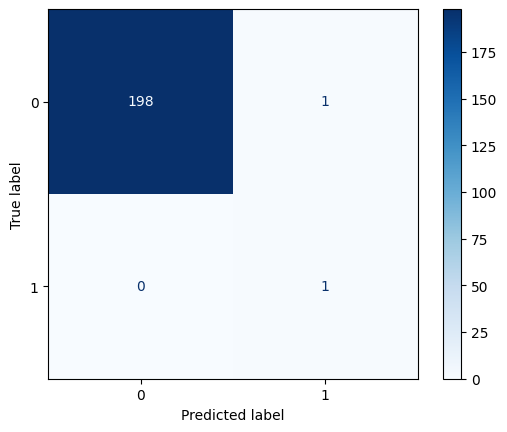

In [6]:
sentences = data["clean_text"]
runs = 1
zero_shot_scores = []

for run in range(runs):
    zero_shot_predictions = []

    for i in trange(len(sentences), desc="Zero-shot / one-shot"):
        sentence = sentences.iloc[i]
        pred = zero_shot(sentence)
        zero_shot_predictions.append(pred)

    export_zero_shot = evaluate_predictions(
        data,
        zero_shot_predictions,
        method_name="Zero-shot / one-shot annotation",
        true_col="elc_ed" # Changed from default 'aggro_human_rm'
    )
    zero_shot_scores.append(summarize_scores(export_zero_shot, "zero-shot / one-shot", true_col="elc_ed")) # Changed from default 'aggro_human_rm'

export_zero_shot.head()
export_zero_shot.to_csv("/content/zero_shot_elced.csv", index=False)
